### Linear regression - example 1 - Work experience vs. yearly salary

In [298]:
# these are usual imports in a classic ML pipeline for Regression
# pip install numpy
# pip install pandas
# pip install seaborn
# pip install scikit-learn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics

### STEP 1 - Load the data

In [299]:
# load the data
csv_path = "https://raw.githubusercontent.com/mk-gurucharan/Regression/master/Salary_Data.csv"
df = pd.read_csv(csv_path)

# let's see the first 5 rows
# there's only 30 rows in total, so this is only a demonstration
# on how to use scikit-learn, the dataset itself is not very useful
df.head()

,YearsExperience,Salary
0,1.1,39343.0
1,1.3,46205.0
2,1.5,37731.0
3,2.0,43525.0
4,2.2,39891.0


### STEP 2: Basic data checks, duplicates or missing values (NaN)?

If your data has text categories (binary, ordinal, nominal), they have to be processed CORRECTLY in this phase as well.

In [300]:
# do we have missing values? apparently not
# DATASET CAN'T HAVE ANY MISSING VALUES when passing the data
# to the machine learning algorithm
df.isna().sum()

YearsExperience    0
Salary             0
dtype: int64

In [301]:
# do we have duplicates
int(df.duplicated().sum())

0

**All data is now prepared and in ALL NUMERIC format (this data didn't have any categories)**

### STEP 3: X/y and train/test -split

In [302]:
# first step, we split our data into SUPPORT variables and the TARGET variable
# X => support variables, y => target variable

# X => list of support variables that the model uses
# while predicting the target variable with the model
X = df[['YearsExperience']]

# our target variable y
y = df['Salary']

In [303]:
# secondly, train/test -split with scikit-learn's helper function
# 0.3 for testing => 30% of the data is reserved for testing purposes (used for metrics later)
# and based on that => it's deduced that 70% will be in the training data

# you can also define the random state, which is sometimes useful
# if you want to "lock down" all the randomness in this part to get same results every time
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=101)

### STEP 4: Create and train the ML model

In [304]:
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[9577.17]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['YearsExperience']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,2.598e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


### STEP 5: Error and performance metrics

In [305]:
# we need to create test predictions based on our earlier reserved test dataset
# this data has never been seen by the model by now
predictions = model.predict(X_test)

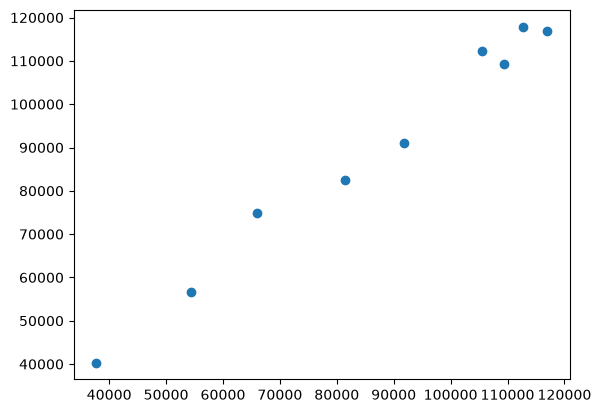

In [306]:
# let's plot how far the predictions are from the real target values (y)
# in the test dataset

# if the values follow a diagonal line (from bottom left to top right)
# => we have good predictions with the model
# we basically compare the predicted values to the actual true values 
# and compare the differences
plt.scatter(y_test, predictions)

In [307]:
# MAE = Mean Absolute Error
mae = metrics.mean_absolute_error(y_test, predictions)
print("MAE: ")
print(f"{round(mae, 2)} $")

# MSE = Mean squared error
mse = metrics.mean_squared_error(y_test, predictions)
print("\nMSE: ")
print(f"{round(mse, 2)} $^2")

# RMSE = Root Mean Square Error
rmse = np.sqrt(mse)
print("\nRMSE: ")
print(f"{round(rmse, 2)} $")

# R-square (or R2) - how well the model describes the original dataset
# 1 => model describes the data perfectly
# 0 => model doesn't describe the data at all
r2 = metrics.r2_score(y_test, predictions)
print("\nR-squared: ")
print(f"{round(r2, 2)}")

MAE: 
3038.68 $

MSE: 
17978409.5 $^2

RMSE: 
4240.1 $

R-squared: 
0.97


In [308]:
# you can compare MAE/RMSE to the average value in order to see
# how off the model is 

# in this case, ~3k$ is fairly OK when compare to the average salary of 76k$
float(df['Salary'].mean())

76003.0

C:\Users\tuomas.valtanen\AppData\Local\Temp\ipykernel_12712\2033131320.py:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot((y_test - predictions))


<Axes: xlabel='Salary', ylabel='Density'>

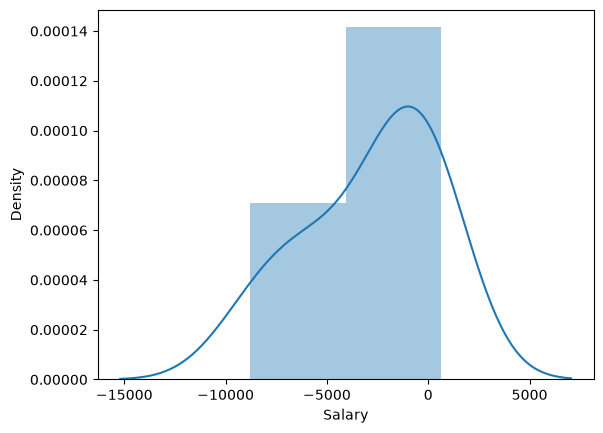

In [309]:
# if the prediction distribution is far from standard normal distribution
# then the model is not probably good enough (should reflect the metrics above)

# distplot is deprecated and will be removed in future seaborn versions
# but no direct replacement has been created so far
sns.distplot((y_test - predictions))

### STEP 6: Testing/using the model in practice (inference)

In [310]:
X.columns

Index(['YearsExperience'], dtype='str')

In [311]:
# usually for the GUI application, we save the model-object / variable 
# into a file (by using joblib-module)
# and in the GUI application => we load the save model from the file
# and use the model just like here below

# let's create a Python -dictionary, containing our test values
# THE VARIABLE NAMES HAVE TO MATCH WITH THE ORIGINAL DATASET
tester_row = {
    "YearsExperience": 9
}

# convert to pandas format
tester_row = pd.DataFrame([tester_row])

In [312]:
# get the output/result from the model
# based on the user's given new data (above code cell)
result = model.predict(tester_row)[0]

print()
print("Predicted salary with the given amount of work experience years:")
print(f"$ {round(float(result), 2)}")
print("------------------------------")


Predicted salary with the given amount of work experience years:
$ 112170.36
------------------------------
